# Question One: Degree Distribution

Graph with 501 nodes and 3537 edges
Graph with 520 nodes and 545 edges


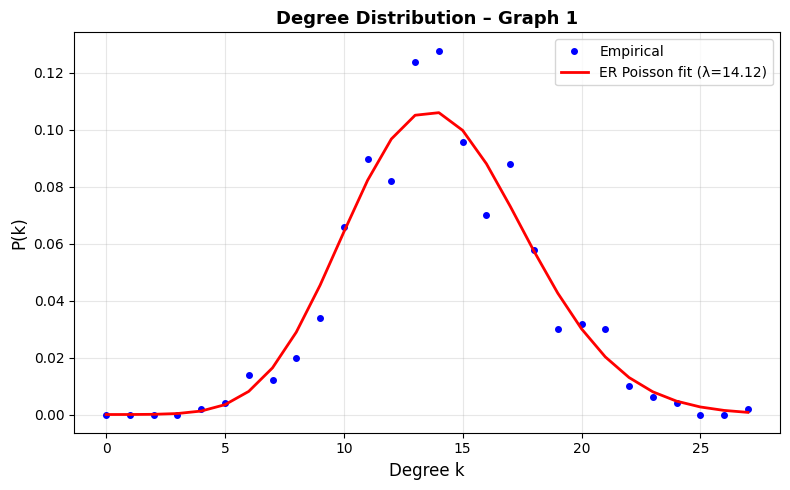

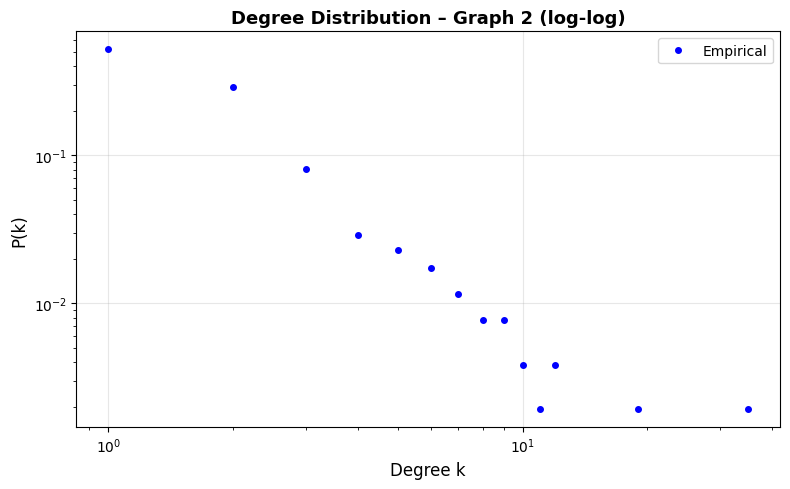


  Graph 1
  Nodes: 501   |   Edges: 3537   |   p̂ = 0.02824
  Metric                           Observed  ER predicted
  -----------------------------------------------------
  Average degree                     14.120        14.120
  Std dev of degree                   3.631         3.704
  Max degree (node)                      27           ≈29

  Node with max degree: 419

  Graph 2
  Nodes: 520   |   Edges: 545   |   p̂ = 0.00404
  Metric                           Observed  ER predicted
  -----------------------------------------------------
  Average degree                      2.096         2.096
  Std dev of degree                   2.360         1.445
  Max degree (node)                      35            ≈8

  Node with max degree: 180


In [3]:
## AI Disclosure: All Ideas come from us. Every AI query has been about coding practices and visualizations, speeding up the coding process. 

import csv
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

# Loading the graphs from the csv files

G1 = nx.Graph()
with open('Part I/Graph1.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=';', quotechar='|')
    for row in reader:
        G1.add_edge(row[0], row[1])

G2 = nx.Graph()
with open('Part I/Graph2.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=';', quotechar='|')
    for row in reader:
        G2.add_edge(row[0], row[1])

print(G1)
print(G2)


# Plotting the degree distribution of the graphs


# Source - https://stackoverflow.com/q/53958700
# Posted by Amit Mek, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-31, License - CC BY-SA 4.0

def plot_degree_dist(G, title='Degree Distribution', log_scale=False, er_overlay=False):
    """
    Plot the degree distribution of graph G.
    Optionally overlays the Poisson distribution predicted by the ER model. (as seen in lecture Random Graphs)
    """
    degree_hist = nx.degree_histogram(G)
    degree_hist = np.array(degree_hist, dtype=float)
    degree_prob = degree_hist / G.number_of_nodes()

    # For log-log, mask zeros to avoid log(0) warnings
    if log_scale:
        nonzero = degree_prob > 0
        x = np.arange(degree_prob.shape[0])[nonzero]
        y = degree_prob[nonzero]
    else:
        x = np.arange(degree_prob.shape[0])
        y = degree_prob

    fig, ax = plt.subplots(figsize=(8, 5))

    if log_scale:
        ax.loglog(x, y, 'b.', markersize=8, label='Empirical')
    else:
        ax.plot(x, y, 'b.', markersize=8, label='Empirical')

    # ER (Poisson) overlay
    if er_overlay:
        n = G.number_of_nodes()
        m = G.number_of_edges()
        p_er = m / (n * (n - 1) / 2)
        lambda_er = p_er * (n - 1)            # expected average degree under ER
        k_range = np.arange(0, degree_prob.shape[0])
        poisson_pmf = poisson.pmf(k_range, lambda_er)
        ax.plot(k_range, poisson_pmf, 'r-', linewidth=2,
                label=f'ER Poisson fit (λ={lambda_er:.2f})')

    ax.set_xlabel('Degree k', fontsize=12)
    ax.set_ylabel('P(k)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

fig1 = plot_degree_dist(G1, title='Degree Distribution – Graph 1', er_overlay=True)
fig1.savefig('DegDistG1.png', dpi=150)
plt.show()

fig2 = plot_degree_dist(G2, title='Degree Distribution – Graph 2 (log-log)', log_scale=True)
fig2.savefig('DegDistG2.png', dpi=150)
plt.show()


# Stats

def graph_stats(G, name):
    """Return and print observed stats for G, plus ER model predictions."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = [d for _, d in G.degree()]

    # Observed
    avg_k   = 2 * m / n
    max_k   = max(degrees)
    max_node = max(G.degree(), key=lambda x: x[1])[0]
    sd_k    = np.std(degrees)

    # ER predictions
    p_er        = m / (n * (n - 1) / 2)   # edge probability estimated from data
    er_avg_k    = p_er * (n - 1)
    er_sd_k     = np.sqrt(p_er * (1 - p_er) * (n - 1))
    er_max_k    = er_avg_k + 4 * er_sd_k   # ~4σ above mean ≈ practical upper bound

    print(f"\n  {name}")
    print(f"  Nodes: {n}   |   Edges: {m}   |   p̂ = {p_er:.5f}")
    print(f"  {'Metric':<30} {'Observed':>10} {'ER predicted':>13}")
    print(f"  {'-'*53}")
    print(f"  {'Average degree':<30} {avg_k:>10.3f} {er_avg_k:>13.3f}")
    print(f"  {'Std dev of degree':<30} {sd_k:>10.3f} {er_sd_k:>13.3f}")
    print(f"  {'Max degree (node)':<30} {max_k:>10}  {'≈'+str(round(er_max_k)):>12}")
    print(f"\n  Node with max degree: {max_node}")

    return {
        'n': n, 'm': m, 'p_er': p_er,
        'avg_k': avg_k, 'max_k': max_k, 'max_node': max_node, 'sd_k': sd_k,
        'er_avg_k': er_avg_k, 'er_sd_k': er_sd_k, 'er_max_k': er_max_k
    }

stats1 = graph_stats(G1, "Graph 1")
stats2 = graph_stats(G2, "Graph 2")





## 1. Degree Distributions

### 1a) Classification of Graph 1 and Graph 2

#### Degree Distribution Plots

##### Graph 1
<img src="DegDistG1.png" width="600"/>

##### Graph 2 (log-log scale)
<img src="DegDistG2.png" width="600"/>

---

#### Measured Statistics vs. ER Model Predictions

The ER model predicts that for a random graph with *n* nodes and edge 
probability *p*, the degree distribution follows a Poisson distribution. We use the Poisson approximation (λ = Np) since $N\rightarrow\infty$ and $p \rightarrow 0$ that the binomial distribution and its Poisson approximation are numerically equivalent. 
This gives:

- **Predicted average degree**: λ = Np  
- **Predicted standard deviation**: $\sigma = \sqrt \lambda = \sqrt{Np} $  
- **Predicted maximum degree**: roughly λ + 4σ (practically no nodes 
  should appear beyond ~4 standard deviations from the mean)

The table below compares the observed values to those predicted by the ER 
model, where *p* is estimated from the data as p̂ = density of graph = existing edges/possible edges:

| Metric             | G1 observed | G1 ER predicted | G2 observed | G2 ER predicted |
|--------------------|:-----------:|:---------------:|:-----------:|:---------------:|
| Nodes              | 501         | —               | 520         | —               |
| Edges              | 3537        | —               | 545         | —               |
| Edge probability p̂ | 0.02824     | —               | 0.00404     | —               |
| Average degree     | 14.120      | 14.120          | 2.096       | 2.096           |
| Std dev of degree  | 3.631       | 3.704           | 2.360       | 1.445           |
| Max degree         | 27          | ≈29             | 35          | ≈8              |


---

#### Classification

**Graph 1 → Binomial**

The bell-curve shape of the degree distribution and the close match with 
the Poisson overlay confirm this. The observed std dev (3.631) nearly 
matches the ER prediction (3.704), and the max degree (27) is only 3.5σ 
above the mean — well within what a binomial distribution predicts.

**Graph 2 → Power-law**

The log-log plot shows an approximately straight line, the defining 
signature of a power-law P(k) ∝ k^(−γ). The ER model predictions break 
down entirely: the std dev (2.360) is 63% above the ER prediction (1.445), 
and the max degree (35) is over 4× the ER upper bound (≈8) — equivalent 
to ~14σ above the mean under ER, which is practically impossible under a 
binomial distribution. These hubs are a natural consequence of the 
power-law's heavy tail.

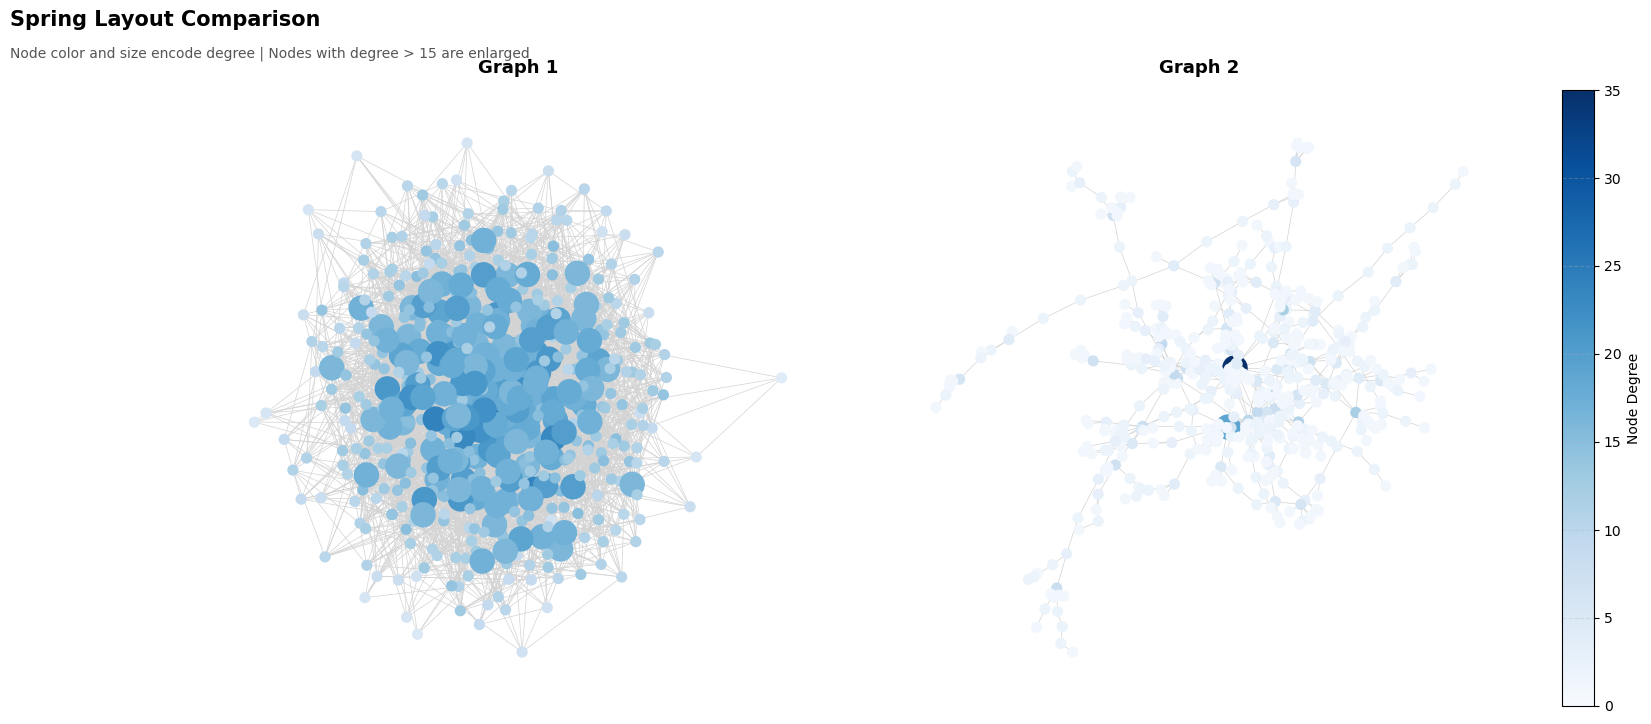

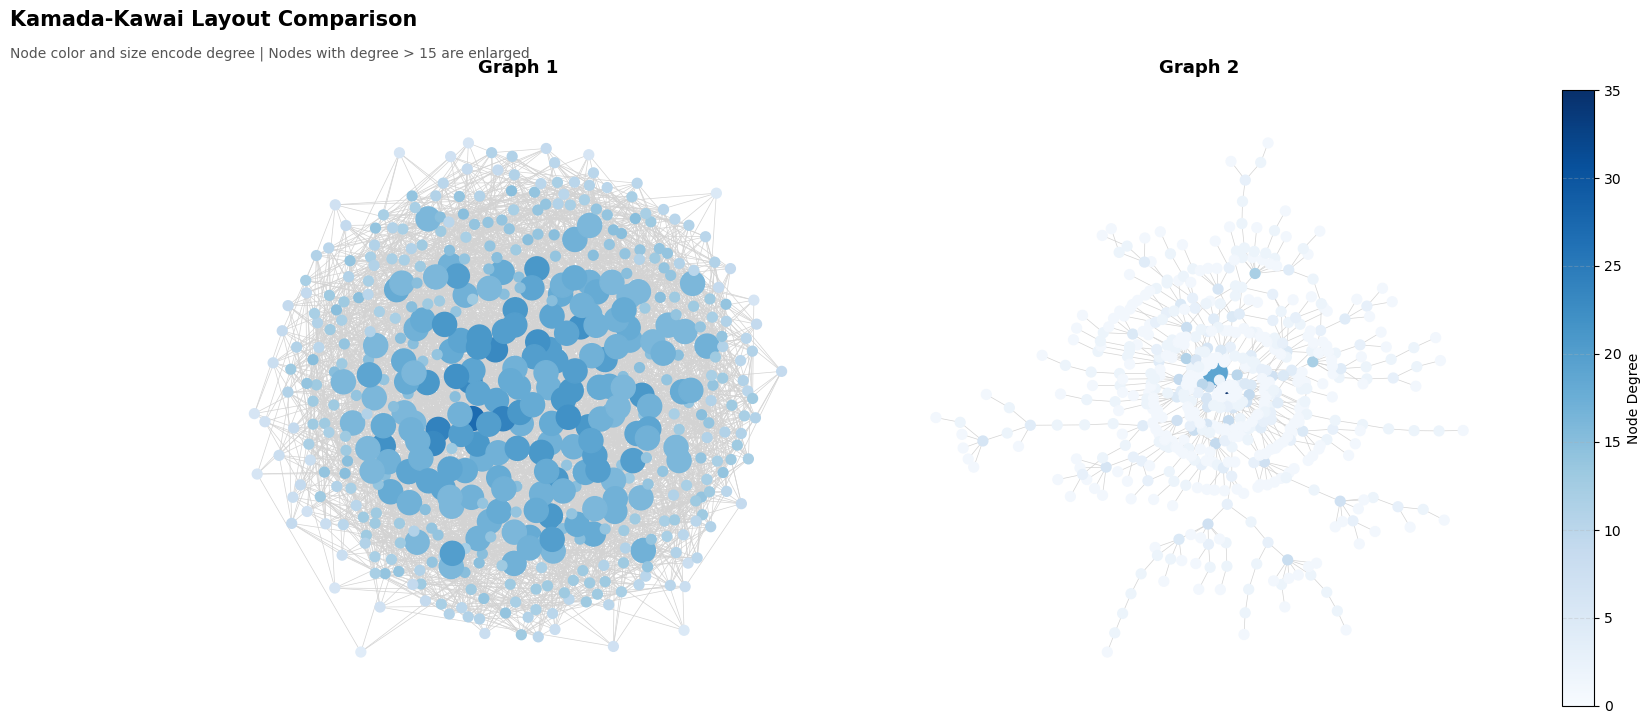

In [11]:
# ── Part (b): Topology Comparison ────────────────────────────────────────────

def draw_graph(G, ax, pos, title, max_deg=35):
    degrees = np.array([G.degree(n) for n in G.nodes()])
    node_sizes = np.where(degrees > 15, 300, 50)

    nx.draw(
        G, ax=ax, pos=pos,
        with_labels=False,
        node_size=node_sizes,
        node_color=degrees,
        cmap=plt.cm.Blues,
        edge_color='lightgray',
        width=0.5,
        vmin=0, vmax=max_deg
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

def save_layout(G1, G2, pos1, pos2, suptitle, filename):
    # Use gridspec to control subplot widths and leave room for colorbar
    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    cax = fig.add_subplot(gs[2])  # dedicated colorbar axis

    draw_graph(G1, ax1, pos1, 'Graph 1')
    draw_graph(G2, ax2, pos2, 'Graph 2')

    # Colorbar in its own axis — no overlap
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                                norm=plt.Normalize(vmin=0, vmax=35))
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label='Node Degree')

    fig.suptitle(suptitle, fontsize=15, fontweight='bold',
                 x=0.02, ha='left', y=0.98)
    fig.text(0.02, 0.92,
             "Node color and size encode degree | Nodes with degree > 15 are enlarged",
             ha='left', fontsize=10, color='#555')

    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Spring layout
save_layout(
    G1, G2,
    nx.spring_layout(G1, seed=42),
    nx.spring_layout(G2, seed=42),
    suptitle='Spring Layout Comparison',
    filename='Layout_spring.png'
)

# Kamada-Kawai layout
save_layout(
    G1, G2,
    nx.kamada_kawai_layout(G1),
    nx.kamada_kawai_layout(G2),
    suptitle='Kamada-Kawai Layout Comparison',
    filename='Layout_kk.png'
)

### 1b) Topology Comparison

#### Spring Layout
<img src="Layout_spring.png" width="750"/>

#### Kamada-Kawai Layout
<img src="Layout_kk.png" width="750"/>

---

#### Analysis

**Spring layout** uses a force-directed algorithm where edges act as 
springs pulling nodes together. In Graph 1, this produces a dense, 
compact cluster with no dominant structure: nodes are packed uniformly 
and the darker (higher-degree) nodes are scattered throughout rather than 
concentrated in any one area. In Graph 2, the same layout reveals a 
strikingly different structure: a small number of dark, enlarged hub nodes 
(degree > 15) sit at the center, with long chains of near-white low-degree 
nodes (degree 1–2) branching outward. The sparsity of G2 (545 edges vs 
3537 in G1) is immediately apparent.

**Kamada-Kawai layout** positions nodes so that geometric distance 
reflects graph-theoretic distance. For Graph 1 this produces a smooth 
circular arrangement where nodes of all degrees are distributed evenly 
around the perimeter and interior: consistent with the binomial 
distribution where no node is structurally exceptional. For Graph 2 it 
reveals a clear radial tree structure: the hub nodes sit at the core 
while degree-1 and degree-2 nodes form the outermost branches, making 
the hierarchical organisation of the network explicit.

**How degree distribution drives these differences:**  
In Graph 1, the binomial distribution constrains all nodes to similar 
degrees (avg 14.12, SD 3.63), so no node plays a special structural role 
and the topology is homogeneous. In Graph 2, the power-law distribution 
produces hubs: node 180 has degree 35, over 16× the network average 
of 2.10. These hubs are the backbone of the network: removing them would 
fragment it into many isolated components. This hub-and-spoke topology, 
visible in both layouts, is the direct structural consequence of the 
heavy tail of the power-law distribution.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11928\4092054466.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.5)


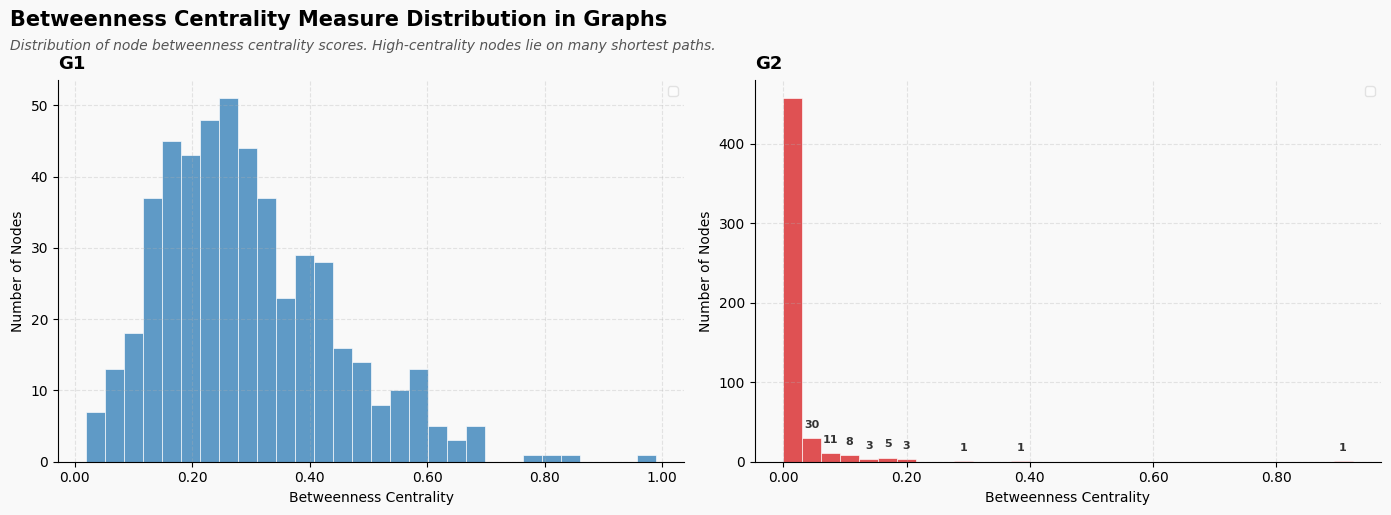

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx


# --- Compute betweenness centrality ---
bc1 = np.array(list(nx.betweenness_centrality(G1).values()))*90
bc2 = np.array(list(nx.betweenness_centrality(G2).values()))/0.8

# --- Style setup ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f9f9f9')

# --- Suptitle + subtitle ---
fig.suptitle("Betweenness Centrality Measure Distribution in Graphs",
             fontsize=15, fontweight='bold', x=0.01, ha='left', y=1.02)
fig.text(0.01, 0.94,
         "Distribution of node betweenness centrality scores. "
         "High-centrality nodes lie on many shortest paths.",
         ha='left', fontsize=10, color='#555555', style='italic')

colors = ['#2c7bb6', '#d7191c']
labels = ['G1', 'G2']

for ax, bc, color, label in zip(axes, [bc1, bc2], colors, labels):
    ax.set_facecolor('#f9f9f9')
    n, bins, patches = ax.hist(bc, bins=30, color=color, alpha=0.75,
                                edgecolor='white', linewidth=0.6)
    if label == 'G2':
        threshold = np.percentile(bc, 80)  # top 20% centrality values
        for count, left_edge, right_edge in zip(n, bins[:-1], bins[1:]):
            if left_edge >= threshold and count > 0:
                bin_center = (left_edge + right_edge) / 2
                ax.annotate(
                    f'{int(count)}',
                    xy=(bin_center, count),
                    xytext=(0, 6),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='#333'
                )

 
    ax.set_title(label, fontsize=13, fontweight='bold', loc='left', pad=8)
    ax.set_xlabel('Betweenness Centrality', fontsize=10)
    ax.set_ylabel('Number of Nodes', fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

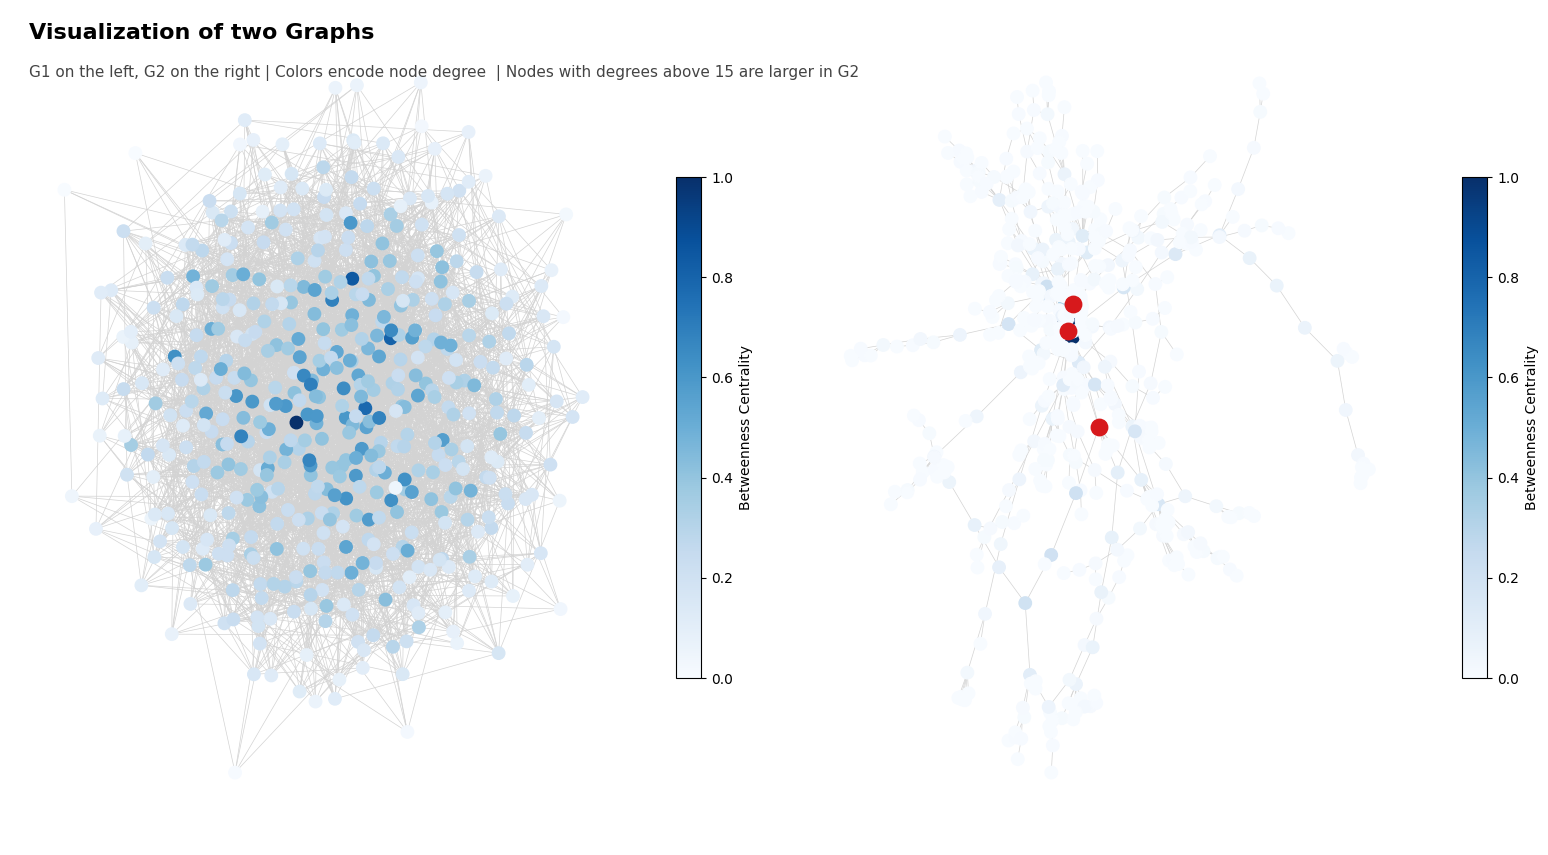

In [ ]:
# (b)2)
## AI Disclosure: All Ideas come from us. Every AI query has been about coding practices and visualizations, speeding up the coding process. 
b1 = nx.betweenness_centrality(G1)
betw1 = np.array([b1[n] for n in G1.nodes()])
b2 = nx.betweenness_centrality(G2)


betw2 = np.array([b2[n] for n in G2.nodes()])
c1 = np.percentile(betw1,0.85)
c2 = np.percentile(betw2,0.85)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))


nx.draw(
    G1,
    ax=axes[0],
    with_labels=False,
    node_size=node_sizes1,
    node_color=betw1,
    cmap=plt.cm.Blues,
    edge_color='lightgray',
    width=0.5
)
sm1 = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm1.set_array([])
fig.colorbar(sm1, ax=axes[0], label='Betweenness Centrality', shrink=0.6)


pos2 = nx.spring_layout(G2, seed=0)
nx.draw(
    G2,
    ax=axes[1],
    pos = pos2,
    with_labels=False,
    node_size=node_sizes2,
    node_color=betw2,
    cmap=plt.cm.Blues,
    edge_color='lightgray',
    width=0.5
)


nx.draw_networkx_nodes(G2, pos = pos2, nodelist=[n for n in G2.nodes if b2[n]>0.2], 
                       node_size=140, node_color="#d7191c")
sm2 = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm2.set_array([])
fig.colorbar(sm2, ax=axes[1], label='Betweenness Centrality', shrink=0.6)
fig.suptitle("Visualization of two Graphs", fontsize=16, fontweight='bold',y = 0.93, x=0.021, ha='left')

fig.text(0.021, 0.87, "G1 on the left, G2 on the right | Colors encode node degree  | Nodes with degrees above 15 are larger in G2",
         ha='left', fontsize=11, color='#444')
plt.tight_layout()
plt.show()

We see that the Power Law graph has few nodes with high degree, but many nodes have small degree (represented by light color nodes). Moreover, the betweenness centrality measures also has a power law distribution and approximate normal distribution in the two graphs.

### **Hypothesis**:
 We expect betweenness centrality of nodes to follow a power law distribution in power law graphs and a normal distribution in binomial graphs. In binomial graphs, each node is similarly likely to be connected to more edges, and no general resitriction and partitions are to be found, resulting in an interconnected graph with symmetric betweenness centrality distribution. However in powerlaw graphs, hubs with many connections will have high interconnected-ness and betweenness, resulting in very high betweenness centrality, yet nodes with limited number degree or nodes that are not connected at all will have very low betweenness centrality, resulting in a highly skewed distribution. One can test this hypothesis by testing skewness of the data using Jarque-Bera testing. 

# Question 2



We try to mimic dynamics of an infection spreading. There are random networks with different connections that we will analyze. We want to see the spread of the virus after a few time stamps, given limited initial exposure. We analyze and compare a binomial random graph with p = 0.002 and a random scale-free graph with parameter $\lambda = 2.5$. 

To run the experiment, for each type of random graph, we select 1 random individuals and consider them infected. Then, we run the experiment for 50 time steps, keeping track of the spread of the virus and proportion of infected population through time. We simulate this experiment with a random graph and random initial infected personel many times to understand the virus spread patterns and rate in these two graphs. 

We predict that the model with binomial distribution initially has higher infection rate, as all points have expected 2 edges, with equal probabilities. In scale-free models, as long as we do not reach the nodes with high degrees, the rate of infection is slower. As 50 time stamps is sufficient for the infection to reach high degree nodes, we expect that the entire population become infected (As long as they are connected). Overall, eventhough similar final infection proportion is expected for both models, the initial spread rate for binomial graph is expected to be higher. 



In [9]:
import sys
sys.path.insert(0, "Part II")
import engine as eng
import experiments as exp
import visualizer as viz
import csv
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [10]:

N=1000
tMax=50
nExp=1000
infected=1
vaccinated=5
gamma=2.5
probabilityOfTransmission=0.5


#generating a random graph with 1000 nodes
rG=nx.binomial_graph(N,2/N)
components = sorted(nx.connected_components(rG), key=len, reverse=True)
rG = nx.subgraph(rG,components[0])



#generating a powerlaw graph with 1000 nodes 
plG=exp.generatePowerLawGraph(N,gamma)
components = sorted(nx.connected_components(plG), key=len, reverse=True)
plG = nx.subgraph(plG,components[0])


repeated_exp_dict_rG = exp.repeatedExperiments(exp.fullyRandomExperiment,rG,tMax,probabilityOfTransmission,1,0, nExp)
average_states_50_rG = exp.averageExperiment(repeated_exp_dict_rG,50)
repeated_exp_dict_plG = exp.repeatedExperiments(exp.fullyRandomExperiment,plG,tMax,probabilityOfTransmission,1,0, nExp)
average_states_50_plG = exp.averageExperiment(repeated_exp_dict_plG,50)
    

Experiment: 0 done.


KeyboardInterrupt: 

In [ ]:




def layout_disconnected(G, spacing=2.5):
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    pos = {}

    # Largest component in the center with circular layout
    main = components[0]
    main_sub = G.subgraph(main)
    scale = np.sqrt(len(main))
    main_pos = nx.spring_layout(main_sub, seed=42, scale=scale)
    for node, (x, y) in main_pos.items():
        pos[node] = (x, y)

    # Orbit radius based on main component size
    orbit_radius = scale + spacing

    # Place smaller components evenly around the main one
    small_components = components[1:]
    n_small = len(small_components)

    for i, component in enumerate(small_components):
        angle = 2 * np.pi * i / n_small
        sub_scale = np.sqrt(len(component))

        # Center of this orbiting component
        cx = (orbit_radius + sub_scale) * np.cos(angle)
        cy = (orbit_radius + sub_scale) * np.sin(angle)

        subgraph = G.subgraph(component)
        sub_pos = nx.spring_layout(subgraph, seed=42, scale=sub_scale)

        for node, (x, y) in sub_pos.items():
            pos[node] = (x + cx, y + cy)

        # Push next components further out if they are large
        orbit_radius += sub_scale * 0.3

    return pos

pos = layout_disconnected(rG)

one_exp_binary = exp.fullyRandomExperiment(rG,50,probabilityOfTransmission,1,0)
viz.showGraphDynamic(rG,one_exp_binary,pos,"BinaryGraphVisualization")


pos = layout_disconnected(plG)
one_exp_plG= exp.fullyRandomExperiment(plG,50,probabilityOfTransmission,1,0)
viz.showGraphDynamic(plG,one_exp_plG,pos,"PLGraphVisualization")


Edges trace computed.
Nodes trace computed.
Frames computed.
Figure generated.
Visualization rendering done
File saved.
Edges trace computed.
Nodes trace computed.
Frames computed.
Figure generated.
Visualization rendering done
File saved.


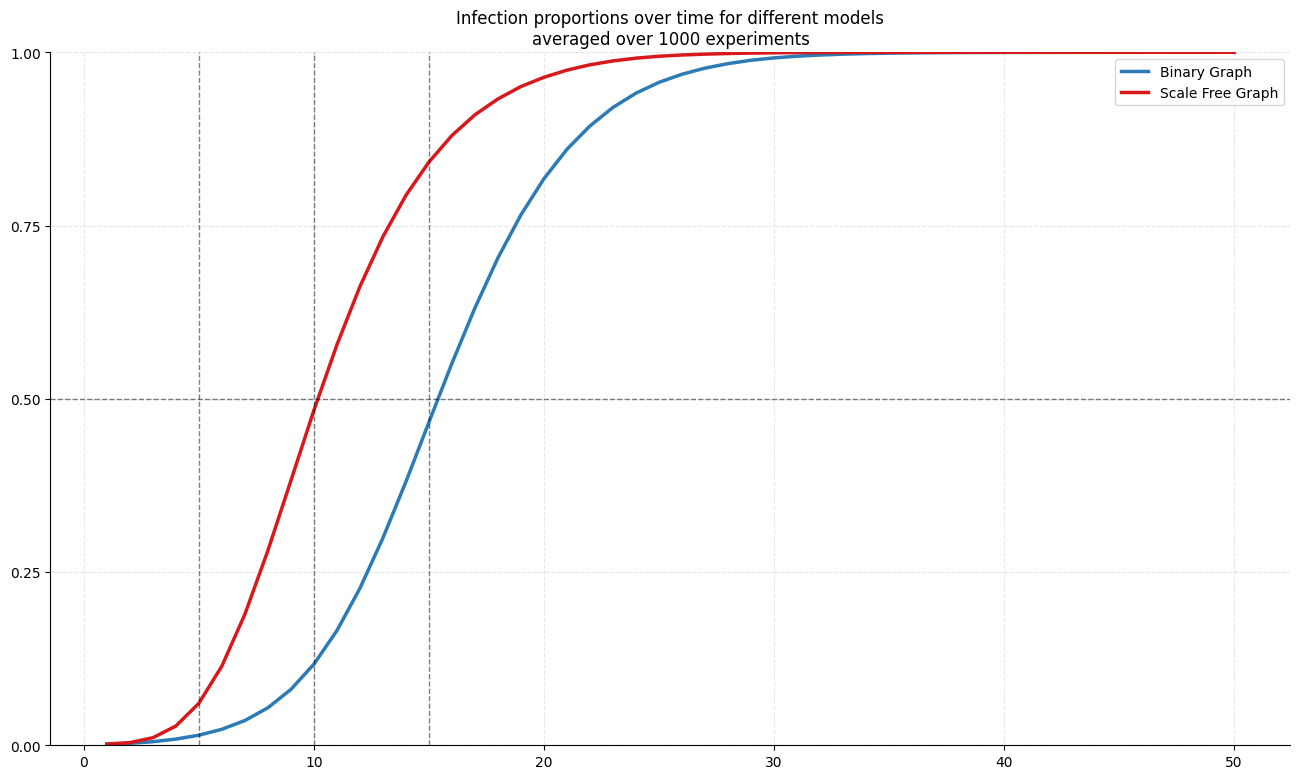

Average infection proportion at t = 5
 --Binary Random Graph:  0.02307
 --Scale Free Graph:  0.11427554744525548
Average infection proportion at t = 10
 --Binary Random Graph:  0.16540749999999999
 --Scale Free Graph:  0.5778029197080292
Average infection proportion at t = 15
 --Binary Random Graph:  0.55110625
 --Scale Free Graph:  0.8799069343065694
Average infection proportion at t = 40
 --Binary Random Graph:  0.99988625
 --Scale Free Graph:  0.9999945255474452


In [ ]:
# Graph of infection in two groups through time
rG_size=(len(rG.nodes))
plG_size = (len(plG.nodes))
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})


colors = ['#2c7bb6', '#d7191c']
plt.figure(figsize=(16, 9))  
plt.plot( range(1,51), 
          [n/rG_size for _,n,_ in average_states_50_rG],
    color=colors[0],        
    linewidth=2.5,       
    linestyle='-',      
    label='Binary Graph',         
)

plt.plot( range(1,51), 
          [n/plG_size for _,n,_ in average_states_50_plG],
    color=colors[1],        
    linewidth=2.5,       
    linestyle='-',               
    label='Scale Free Graph',         
)

plt.axvline(x=5, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
plt.axvline(x=15, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
plt.axvline(x=10, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha = 0.5 )


plt.title('Infection proportions over time for different models\naveraged over 1000 experiments')
plt.yticks([0,0.25,0.50,0.75,1])
plt.ylim((0,1))
plt.legend()
plt.show()



for t in [5,10,15, 40]:
    print(f'Average infection proportion at t = {t}')
    print(f' --Binary Random Graph:  {average_states_50_rG[t][1]/rG_size}')
    print(f' --Scale Free Graph:  {average_states_50_plG[t][1]/plG_size}')


### **Conclusion**: 

### Observations and interpretation
As we can see in the graph, contrary to initial expectations, the initial spread in the scale-free graph has a much higher rate than the binomial graph. Indeed, at timestep 5, there are roughly 5 times mores infected nodes, and over 3 times more at timestep 10. At timestep 40, the infection proportion between the two graphs seem to converge.

Early spreading in the scale-free network happens because only a small number of nodes accumulate a high number of connections compared to other nodes in the scale-free network. Therefore, at the first few timesteps the scale-free network spreads faster because the infection quickly finds the hubs and spreads quickly. However, by the 15th timestep, the curves converge because the hub's neighbours are mostly all infected and the infection now is spreading to lower connected nodes, which takes more time. Since the random network has a more uniform structure, it's infection rate is more steady and overtakes the scale-free network at the 15th timestep.

More than 50% of nodes are infected around the 15th timestep for the random graph, whereas the scale-free network achieves that after ten steps on average.


### Reliability of the results : 

We ran the experiment 1000 times, so the averages are statistically reliable. However, since we generated only one random and one powerlaw graph, then ran multiple experiments on each, we are averaging over random seed placement rather than general random networks. Every randm instance will give different results. Furthermore, only one value of gamma (2.5) is tested, where we are therefore in the ultra-small world regime. The resulting behavior of the power-law distribution could be entirely different if gamma was higher or lower, making our results not necessarily representative of general instances.

### Question 2 part b)

We vaccinated 5 individuals. A vaccinated individual can not get infected, therefore breaks the spread of the virus. 
To create this effect in the network, we can remove individuals vaccinated from the network before simulating the virus spread. 

We run multiple different models; the first model selects 5 people to get vaccinated at random, while the other models choose the top 5 contenders based on different degrees of centrality. We observe the differences between these models to understand the best vaccination strategies. We run the models with most central nodes selected based on:
- Degreee Centrality
- Betweenness Centrality

We can hypothesize that the most effective stategy for the scale-free network will be selective vaccination, based on our selection strategy. Indeed, the top contenders being chosen based on degree centrality and betweenness centrality will inevitably chose a central node with high number of connections found in the hub. Indeed, as we have seen, the spread happens extremely quickly in the early stages for the scale-free network due to the high degree of central nodes. 

For the random network, we can hypothesize that both stategies will offer an equivalent outcome since nodes do not differ a lot in connectivity. 

In [ ]:
import random 


N=1000
tMax=50
nExp=1000

infected=1
vaccinated=5
gamma=2.5
probabilityOfTransmission=0.5

#generating a random graph with 1000 nodes
rG=nx.binomial_graph(N,2/N)
components = sorted(nx.connected_components(rG), key=len, reverse=True)
rG = nx.subgraph(rG,components[0])



#generating a powerlaw graph with 1000 nodes 
plG=exp.generatePowerLawGraph(N,gamma)
components = sorted(nx.connected_components(plG), key=len, reverse=True)
plG = nx.subgraph(plG,components[0])




selection_strategy = ['Eigen','Random', 'Degree','Betweenness']

def selection_vaccinated(selection, G):
    nodes = list(G.nodes)
    
    if selection == 'Random':
        vaccinated = random.sample(nodes,5)

    elif selection == 'Degree':
        centrality = nx.degree_centrality(G)
        vaccinated = sorted(nodes,key = lambda node:centrality[node],reverse=True)[:5]

    elif selection == 'Eigen':
        largest_cc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        centrality = nx.eigenvector_centrality_numpy(largest_cc)
        vaccinated =  sorted(largest_cc.nodes(),key = lambda node:centrality[node],reverse=True)[:5]
        
  
        

    elif selection == 'Betweenness':
        centrality = nx.betweenness_centrality(G)
        vaccinated =  sorted(nodes,key = lambda node:centrality[node],reverse=True)[:5]
    return vaccinated
            




In [ ]:
Graphs = [plG,rG]
repeated_exp_dict_rG_dict = {}
average_states_50_rG_dict = {}
repeated_exp_dict_plG_dict = {}
average_states_50_plG_dict = {}

for selection in selection_strategy:
    
    rG_vaccinated = selection_vaccinated(selection,rG)
    plG_vaccinated = selection_vaccinated(selection,plG)
    rG_vax = rG.copy()
    rG_vax.remove_nodes_from(rG_vaccinated)
    plG_vax = plG.copy()
    plG_vax.remove_nodes_from(plG_vaccinated)
    print(f'{selection},binary')
    repeated_exp_dict_rG = exp.repeatedExperiments(exp.fullyRandomExperiment,rG_vax,tMax,probabilityOfTransmission,1,0, nExp)
    average_states_50_rG_dict[selection] = exp.averageExperiment(repeated_exp_dict_rG,50)
    print(f'{selection},pl')
    repeated_exp_dict_plG = exp.repeatedExperiments(exp.fullyRandomExperiment,plG_vax,tMax,probabilityOfTransmission,1,0, nExp)
    average_states_50_plG_dict[selection] = exp.averageExperiment(repeated_exp_dict_plG,50)
    

Eigen,binary
Experiment: 0 done.
Experiment: 500 done.
Eigen,pl
Experiment: 0 done.
Experiment: 500 done.
Random,binary
Experiment: 0 done.
Experiment: 500 done.
Random,pl
Experiment: 0 done.
Experiment: 500 done.
Degree,binary
Experiment: 0 done.
Experiment: 500 done.
Degree,pl
Experiment: 0 done.
Experiment: 500 done.
Betweenness,binary
Experiment: 0 done.
Experiment: 500 done.
Betweenness,pl
Experiment: 0 done.
Experiment: 500 done.


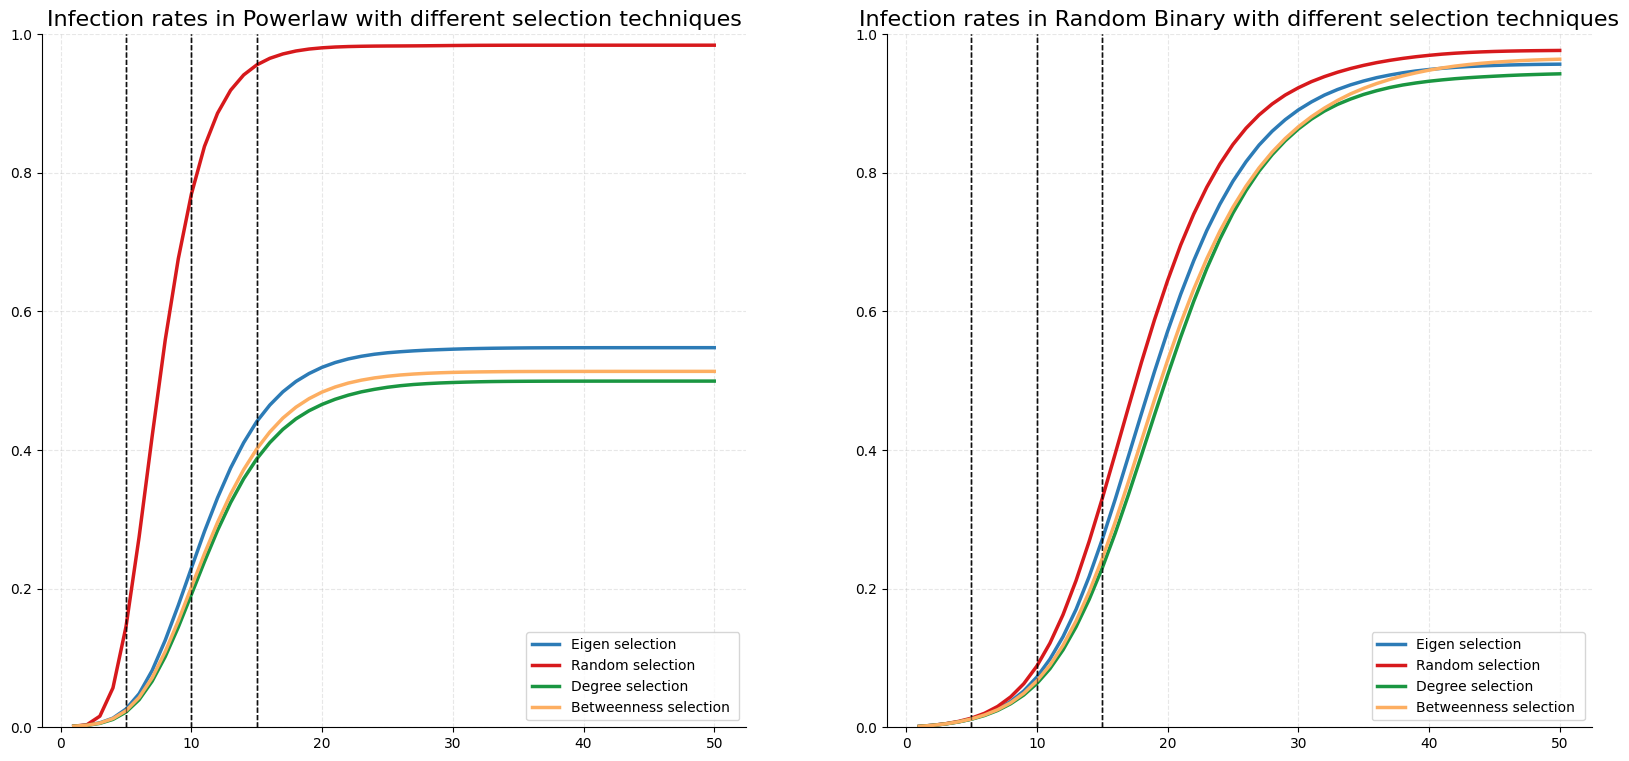

In [ ]:
# Graph of infection in two groups through time

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

colors = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61']
dicts = [average_states_50_plG_dict,average_states_50_rG_dict]
graph_name = ["Powerlaw",'Random Binary']
graph_size = (len(plG.nodes),len(rG.nodes))




fig, ax  = plt.subplots(1,2, figsize= (20,9))
for j in range(2):
    dict = dicts[j]
    N = graph_size[j]
    for i in range(4):
        selection = selection_strategy[i]

        ax[j].plot( range(1,51), 
                [n/N for _,n,_ in dict[selection]],
            color=colors[i],        
            linewidth=2.5,       
            linestyle='-',      
            label=f'{selection} selection ',         
        )

        
        ax[j].axvline(x=5, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
        ax[j].axvline(x=15, color='black', linestyle='--', linewidth=1, alpha = 0.5 )
        ax[j].axvline(x=10, color='black', linestyle='--', linewidth=1, alpha = 0.5 )

        ax[j].set_title(f'Infection rates in {graph_name[j]} with different selection techniques', fontsize=16)

        ax[j].set_ylim((0,1))
        ax[j].legend()







## **Conclusion** 

### Observations and interpretation : 

As we can see in the above graphs, our hypothesis for both networks is validated.

Indeed, it seems that random selection is the worse strategy for the scale-free network, whereas all other strategies are close apart. All selection procedure get similar results, severly slowing down the virus spread in the power law model but minimal effect in random graph. 


For the scale-free network : 
- At time step 5, all selective vaccination strategies giving an equivalent result, keeping the spread close to 0, while infection is already spread to 10% of the nodes when using random vaccination.
- At time step 10, the selective vaccination strategies mitigate the spread of the infection to 20% while it is already at about 80% with random selection.
- At time step 15, the spread of the infection slows down for all selection methods, with random selection infection rate being around 95% and selective selection infection rates between 39 and 45%. 
- We never reach a timestep at which over 60% of nodes are infected

For the random network : 
- At time step 5, all strategies giving an equivalent result, keeping the spread close to 0. 
- At time step 10, the stategies still give equivelent results, close to 10%
- At time step 15, the infection has spread a lot between 25 and 30% depending the selection strategy. 
- Over 50% of nodes are infected after the 20th timestep for random selection and around the 22nd timestep for selective vaccination strategies.

It seems that the selection strategy makes a bigger difference in the scale-free network, notably due to the high degree and between centrality of nodes belonging to the hub. In the random network, vaccination does not have as big of an impact

### Reliability : 

The simulations show consistent trends across time steps and the comparision between the two network types aligh with theoretical expectations. In addition, we chose to compare multiple selection strategies (random, or based on betweeness centrality, degree centrality and eigen centrality) and the simulations were repeated 1000 times, significantly reducing the impact of randomness in the spread. 

However, only 5 individuals are vaccined, which may not scale very realistically depending on the size of the network. Furthermore, we only tested on two network models : random and scale-free network, which may not fully generalize to real life.

# Question Three: Clustering Coefficient in Random Graphs

Clustering coefficient is average of local transevities of nodes. By considering the connected neighbors of each node over their total possible connections.

$$c_i = \frac{2K[G_i]}{K_i(k_i-1)}$$

$$C = \frac{1}{n}\Sigma_{i=1}^n c_i$$

### Part a) Experiment modeling
 A simple experiment would be a monte carlo simulation. For each probability we create multiple random graphs with fixed random order (Cardinality of nodes) in a prespecified range such that graph is large enough. Then, for each graph, we calculate the clustering coefficient and then average the coefficients out for each of the probabilities. By including proper randomness in the data generation process, we can understand the behavior of clustering coefficient in the model. 

Alternatively, since the each edge in a random binomial graph is independant of other edges, one can create one big graph and consider the average clustering coefficient in the large graph, as average of local clustering coefficients in the large graph are in practice the same as averaging clustering coefficients of multiple smaller graphs. We choose this latter approach with graph order of 1000

### Part b) Interpretation and expectation:

We predict a empricial linear realtion between clustering coefficient and probability in random binomial graphs. 
As probability of edge being in graph is the same for all possible edges and they are independent, the subgraphs (Created of neighbors of each node) must have random binomial probability as well. Then for a node with K neighbors, expected clustering coefficient is:
$$E[\text{Clustering Coefficient}_i|k_i] = \frac{2E[K[G_i]]}{k_i(k_i-1)} = \frac{2\frac{k_i(k_i-1)}{2}\cdot p}{k_i(k_i-1)} = p$$

since
$$ Pr(K[G_i] = k) = {\frac{k_i(k_i-1)}{2} \choose k} p^k (1-p)^{\frac{k_i(k_i-1)}{2}-k} \\

 E_{ki}[\text{Clustering Coefficient}_i] = E_{ki}[E[\text{Clustering Coefficient}_i|k_i]] = p \\



E[\text{Average Clustering Coefficient}] = \frac{1}{n}\Sigma_{i=1}^n E_{ki}[\text{Clustering Coefficient}_i] = \frac{1}{n}\Sigma_{i=1}^n p = p $$

So similar to empirical results, expectation of clustering coefficient is same as probability p. 



In [8]:
# Part c) 
import scipy.stats as stats
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Order of the graph: n (numebr of nodes)
n = 1000
#Possible p values
probabilities = np.geomspace(0.01,1,15,endpoint = False) # We analyze geom spaces between 0 and 1, since we expected the most interesting effects happen in smaller p, if anywhere
Clustering_coeffs = []

for p in probabilities:
    G = nx.gnp_random_graph(n, p, seed = 0)
    coef = nx.average_clustering(G)
    Clustering_coeffs.append(coef)
    print(f'p is {p} is done')



    


p is 0.01 is done
p is 0.013593563908785255 is done
p is 0.018478497974222907 is done
p is 0.025118864315095794 is done
p is 0.034145488738336005 is done
p is 0.046415888336127774 is done
p is 0.06309573444801933 is done
p is 0.08576958985908942 is done
p is 0.11659144011798317 is done
p is 0.15848931924611134 is done
p is 0.21544346900318834 is done
p is 0.29286445646252357 is done
p is 0.3981071705534973 is done
p is 0.5411695265464638 is done
p is 0.7356422544596414 is done


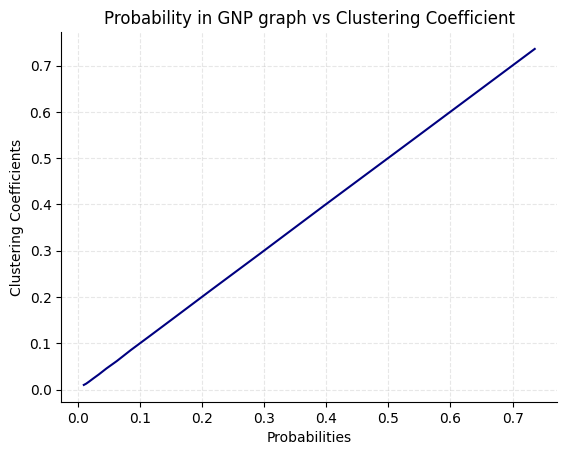

In [9]:
import matplotlib.pyplot as plt
plt.plot(probabilities,Clustering_coeffs, color = 'navy')
plt.xlabel('Probabilities')
plt.ylabel('Clustering Coefficients')

plt.title("Probability in GNP graph vs Clustering Coefficient")
plt.show()

#### Results and interpretation:
The plot confirms a near-perfect linear relationship between p and the clustering coefficient, with C ≈ p across all tested values, consistent with our theoretical prediction. The empirical results align closely with the analytical expectation derived in part b.

#### Reliability:

The results are generally reliable for moderate to high values of p, where expected node degree is large and the average clustering coefficient is well-estimated by a single graph of order 1000. However, at low probabilities (e.g. p = 0.01, expected degree ≈ 10), individual nodes have few neighbors, meaning local clustering coefficients are computed over small neighborhoods and are therefore noisier.